# Aprendizaje Supervisado con Favorita Grocery Sales
## Predicción de demanda semanal con enfoque de Data Engineering

**Diplomado en Data Engineering — Módulo de Machine Learning**

Este cuaderno continúa el módulo anterior y parte directamente desde `Favorita_weekly.parquet`.

El archivo semanal contiene las siguientes variables:

- `fecha_semana`: fecha de inicio de la semana;
- `anio`: año calendario;
- `semana`: número de semana dentro del año;
- `store_nbr`: identificador de la tienda;
- `item_nbr`: identificador del producto;
- `unit_sales`: unidades vendidas durante la semana;
- `dias_promocion`: cantidad de días de la semana en que el producto estuvo en promoción;
- `dias_con_venta`: cantidad de días de la semana en que se registraron ventas.

La variable `semana` se repite cada año. Por ello:

- `fecha_semana` se utilizará como identificador temporal único;
- `semana_id` representará el orden cronológico mediante un correlativo.

> **Idea central:** antes de entrenar los modelos debemos representar correctamente la dimensión temporal.


# 1. Importación de librerías

Google Colab ya incluye las librerías utilizadas. No realizaremos instalaciones automáticas.
También importaremos herramientas para medir el tiempo de cada proceso.


In [2]:
from pathlib import Path
from time import perf_counter
from datetime import datetime

import numpy as np
import pandas as pd
import polars as pl

import plotly.express as px
import plotly.graph_objects as go

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from xgboost import XGBRegressor, XGBClassifier
import joblib

RANDOM_STATE = 42



# 2. Registro de tiempos

La función siguiente almacenará el inicio, fin y duración de cada proceso relevante.


In [3]:
registro_tiempos = []
inicio_laboratorio_perf = perf_counter()

def registrar_tiempo(proceso, inicio_perf, inicio_dt):
    fin_dt = datetime.now()
    duracion = perf_counter() - inicio_perf
    registro_tiempos.append({
        'Proceso'     : proceso,
        'Inicio'      : inicio_dt,
        'Fin'         : fin_dt,
        'Duración (s)': duracion
    })
    print(f'{proceso}: {duracion:.2f} segundos')
    return duracion


# 3. Carga de `Favorita_weekly.parquet`

El archivo debe estar en `/content/Favorita_weekly.parquet`. Modifica la ruta si es necesario.


In [4]:
RUTA_ARCHIVO = Path('/content/favorita_weekly.parquet')

if not RUTA_ARCHIVO.exists():
    raise FileNotFoundError(
        f'No se encontró {RUTA_ARCHIVO}. Súbelo a Colab o modifica la ruta.'
    )

inicio_perf    = perf_counter(); inicio_dt = datetime.now()
df             = pl.read_parquet(RUTA_ARCHIVO)
tiempo_lectura = registrar_tiempo('Lectura del archivo Parquet', inicio_perf, inicio_dt)

print(f'Filas    : {df.height:,}')
print(f'Columnas : {df.width}')


Lectura del archivo Parquet: 0.92 segundos
Filas    : 23,582,329
Columnas : 8


# 4. Revisión inicial del dataset


In [6]:
print('Columnas disponibles :')
print(df.columns)
print('Tipos de datos       :')
print(df.schema)
df.head()


Columnas disponibles :
['fecha_semana', 'anio', 'semana', 'store_nbr', 'item_nbr', 'unit_sales', 'dias_promocion', 'dias_con_venta']
Tipos de datos       :
Schema({'fecha_semana': Datetime(time_unit='ns', time_zone=None), 'anio': Int16, 'semana': Int8, 'store_nbr': Int16, 'item_nbr': Int32, 'unit_sales': Float32, 'dias_promocion': Int8, 'dias_con_venta': Int8})


fecha_semana,anio,semana,store_nbr,item_nbr,unit_sales,dias_promocion,dias_con_venta
datetime[ns],i16,i8,i16,i32,f32,i8,i8
2012-12-31 00:00:00,2013,1,1,103520,5.0,0,2
2012-12-31 00:00:00,2013,1,1,103665,13.0,0,5
2012-12-31 00:00:00,2013,1,1,105574,26.0,0,5
2012-12-31 00:00:00,2013,1,1,105575,38.0,0,5
2012-12-31 00:00:00,2013,1,1,105577,11.0,0,5


# 5. Preparación del conjunto de datos

El archivo fue construido en el módulo anterior y sus columnas ya son conocidas.

En esta sección:

1. seleccionamos las variables necesarias;
2. renombramos las columnas para facilitar su interpretación;
3. conservamos `anio` y `semana`;
4. creamos `semana_id`, un correlativo temporal que no se reinicia al cambiar de año.


In [7]:
# ============================================================
# Columnas utilizadas en el laboratorio
# ============================================================

df = (
    df
    .select([
        pl.col("fecha_semana")
          .cast(pl.Date)
          .alias("fecha_semana"),

        pl.col("anio")
          .cast(pl.Int16)
          .alias("anio"),

        pl.col("semana")
          .cast(pl.Int8)
          .alias("semana"),

        pl.col("store_nbr")
          .alias("tienda"),

        pl.col("item_nbr")
          .alias("producto"),

        pl.col("unit_sales")
          .cast(pl.Float64)
          .alias("ventas"),

        pl.col("dias_promocion")
          .cast(pl.Int8)
          .fill_null(0)
          .alias("dias_promocion"),

        pl.col("dias_con_venta")
          .cast(pl.Int8)
          .fill_null(0)
          .alias("dias_con_venta")
    ])
    .with_columns(
        pl.col("fecha_semana")
          .rank(method="dense")
          .cast(pl.Int32)
          .alias("semana_id")
    )
    .sort([
        "fecha_semana",
        "tienda",
        "producto"
    ])
)

df.head()


fecha_semana,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta,semana_id
date,i16,i8,i16,i32,f64,i8,i8,i32
2012-12-31,2013,1,1,103520,5.0,0,2,1
2012-12-31,2013,1,1,103665,13.0,0,5,1
2012-12-31,2013,1,1,105574,26.0,0,5,1
2012-12-31,2013,1,1,105575,38.0,0,5,1
2012-12-31,2013,1,1,105577,11.0,0,5,1


## Identificadores temporales

- `semana`: número de semana dentro del año; puede repetirse en años distintos.
- `fecha_semana`: fecha real que identifica de manera única el período.
- `semana_id`: correlativo temporal utilizado como variable numérica y para dividir entrenamiento y prueba.

Por ejemplo, la semana 1 de 2016 y la semana 1 de 2017 tienen el mismo número de semana, pero distinta `fecha_semana` y distinto `semana_id`.


In [8]:
df.select([
    "fecha_semana",
    "semana_id",
    "anio",
    "semana",
    "tienda",
    "producto",
    "ventas",
    "dias_promocion",
    "dias_con_venta"
]).head()


fecha_semana,semana_id,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta
date,i32,i16,i8,i16,i32,f64,i8,i8
2012-12-31,1,2013,1,1,103520,5.0,0,2
2012-12-31,1,2013,1,1,103665,13.0,0,5
2012-12-31,1,2013,1,1,105574,26.0,0,5
2012-12-31,1,2013,1,1,105575,38.0,0,5
2012-12-31,1,2013,1,1,105577,11.0,0,5


# 7. Calidad de datos: nulos


In [ ]:
df.select([
    pl.col(c).null_count().alias(c)
    for c in [
        "fecha_semana",
        "semana_id",
        "anio",
        "semana",
        "tienda",
        "producto",
        "ventas",
        "dias_promocion",
        "dias_con_venta"
    ]
])


fecha_semana,semana_id,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


In [10]:
df.null_count()

fecha_semana,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta,semana_id
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0


# 8. Calidad de datos: última semana y duplicados

Primero se elimina la última fecha semanal, porque corresponde a una semana incompleta.
Después se verifica la unicidad de la llave lógica:

**fecha_semana + tienda + producto**


In [11]:
# ============================================================
# Eliminar la última semana incompleta
# ============================================================

ultima_fecha = df.select(pl.max("fecha_semana")).item()

print(f"Última fecha semanal : {ultima_fecha}")

df = df.filter(pl.col("fecha_semana") != ultima_fecha)

print(f"Nueva última fecha   : {df.select(pl.max('fecha_semana')).item()}")
print(f"Registros restantes  : {df.height:,}")


Última fecha semanal : 2017-08-14
Nueva última fecha   : 2017-08-07
Registros restantes  : 23,461,742


In [12]:
duplicados = (
    df
    .group_by(["fecha_semana", "tienda", "producto"])
    .len()
    .filter(pl.col("len") > 1)
)

print(f"Combinaciones duplicadas: {duplicados.height:,}")
duplicados.head()


Combinaciones duplicadas: 0


fecha_semana,tienda,producto,len
date,i16,i32,u32


# **9. Selección de los productos de mayor venta**

Para disminuir el costo computacional del entrenamiento, se evaluarán distintos subconjuntos formados por los productos de mayor volumen de ventas. Posteriormente se seleccionará un único subconjunto para el resto del laboratorio.

# **Celda 9.1 - Evaluación de distintas cantidades de productos**

In [13]:
# ============================================================
# Evaluación de distintos números de productos
# ============================================================

# Ventas acumuladas por producto
ventas_producto = (
    df
    .group_by("producto")
    .agg(
        pl.col("ventas")
          .sum()
          .alias("ventas_totales")
    )
    .sort("ventas_totales", descending=True)
)

productos_disponibles = ventas_producto.height
ventas_totales        = ventas_producto["ventas_totales"].sum()

print("=" * 75)
print(f"Productos disponibles: {productos_disponibles:,}")
print("=" * 75)

for n in [100, 250, 500]:

    productos_n = (
        ventas_producto
        .head(n)
        .get_column("producto")
        .to_list()
    )

    registros = (
        df
        .filter(
            pl.col("producto").is_in(productos_n)
        )
        .height
    )

    ventas = (
        ventas_producto
        .head(n)
        .get_column("ventas_totales")
        .sum()
    )

    porcentaje = ventas / ventas_totales * 100

    print(
        f"Top {n:3d} productos | "
        f"Registros: {registros:>10,} | "
        f"Ventas representadas: {porcentaje:6.2f}%"
    )

print("=" * 75)

Productos disponibles: 4,035
Top 100 productos | Registros:    929,109 | Ventas representadas:  20.22%
Top 250 productos | Registros:  2,279,061 | Ventas representadas:  34.35%
Top 500 productos | Registros:  4,478,401 | Ventas representadas:  49.10%


### Selección del subconjunto de productos

A partir de la evaluación anterior, se seleccionarán los **250 productos de mayor volumen de ventas**.

Esta cantidad permite reducir aproximadamente a la mitad el número de registros, manteniendo la mayor parte del volumen total de ventas y disminuyendo el costo computacional del entrenamiento de los modelos.

# **Celda 9.2 - Aplicar la selección definitiva**

In [14]:
# ============================================================
# Selección definitiva de productos
# ============================================================

TOP_PRODUCTOS = 250

# Productos seleccionados
productos_top = (
    ventas_producto
    .head(TOP_PRODUCTOS)
    .get_column("producto")
    .to_list()
)

filas_antes = df.height

# Filtrar dataset
df = (
    df
    .filter(
        pl.col("producto").is_in(productos_top)
    )
)

filas_despues = df.height

# Ventas representadas
ventas_seleccionadas = (
    ventas_producto
    .head(TOP_PRODUCTOS)
    .get_column("ventas_totales")
    .sum()
)

participacion_ventas = (
    ventas_seleccionadas / ventas_totales
) * 100

reduccion = (
    1 - filas_despues / filas_antes
) * 100

print("=" * 75)
print("SELECCIÓN DEFINITIVA DEL DATASET")
print("=" * 75)
print(f"Productos disponibles    : {productos_disponibles:,}")
print(f"Productos seleccionados  : {TOP_PRODUCTOS:,}")
print(f"Tiendas conservadas      : {df['tienda'].n_unique():,}")
print(f"Filas antes              : {filas_antes:,}")
print(f"Filas después            : {filas_despues:,}")
print(f"Reducción de registros   : {reduccion:.2f}%")
print(f"Ventas representadas     : {participacion_ventas:.2f}%")
print("=" * 75)

SELECCIÓN DEFINITIVA DEL DATASET
Productos disponibles    : 4,035
Productos seleccionados  : 250
Tiendas conservadas      : 54
Filas antes              : 23,461,742
Filas después            : 2,279,061
Reducción de registros   : 90.29%
Ventas representadas     : 34.35%


In [15]:
df

fecha_semana,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta,semana_id
date,i16,i8,i16,i32,f64,i8,i8,i32
2012-12-31,2013,1,1,105575,38.0,0,5,1
2012-12-31,2013,1,1,111223,29.0,0,5,1
2012-12-31,2013,1,1,114790,27.0,0,4,1
2012-12-31,2013,1,1,115611,146.0,0,5,1
2012-12-31,2013,1,1,115850,5.0,0,3,1
…,…,…,…,…,…,…,…,…
2017-08-07,2017,32,54,1962621,575.0,0,7,241
2017-08-07,2017,32,54,1963277,164.0,1,7,241
2017-08-07,2017,32,54,2010902,182.0,0,7,241


In [25]:
ventas_semanales = (
    df
    .group_by([
        "fecha_semana",
        "semana_id"
    ])
    .agg([
        pl.col("ventas")
          .sum()
          .alias("ventas_totales"),

        pl.col("tienda")
          .n_unique()
          .alias("n_tiendas"),

        pl.col("producto")
          .n_unique()
          .alias("n_productos"),

        pl.col("dias_promocion")
          .sum()
          .alias("dias_promocion_totales"),

        pl.col("dias_con_venta")
          .sum()
          .alias("dias_con_venta_totales")
    ])
    .sort("fecha_semana")
    .with_columns(
        pl.col("ventas_totales")
          .rolling_mean(window_size=4)
          .alias("promedio_4s")
    )
)

ventas_semanales_pd = ventas_semanales.to_pandas()

ventas_semanales_pd["fecha_fin_semana"] = (
    pd.to_datetime(ventas_semanales_pd["fecha_semana"])
    + pd.Timedelta(days=6)
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=ventas_semanales_pd["fecha_semana"],
        y=ventas_semanales_pd["ventas_totales"],
        mode="lines+markers",
        name="Ventas totales",
        customdata=ventas_semanales_pd[
            [
                "semana_id",
                "fecha_fin_semana",
                "n_tiendas",
                "n_productos",
                "dias_promocion_totales",
                "dias_con_venta_totales"
            ]
        ],
        hovertemplate=(
            "<b> Cantidades totales</b><br>"
            "Semana correlativa: %{customdata[0]}<br>"
            "Inicio: %{x|%d-%m-%Y}<br>"
            "Fin: %{customdata[1]|%d-%m-%Y}<br>"
            "Ventas: %{y:,.0f}<br>"
            "Tiendas: %{customdata[2]}<br>"
            "Productos: %{customdata[3]:,.0f}<br>"
            "Días en promoción acumulados: %{customdata[4]:,.0f}<br>"
            "Días con venta acumulados: %{customdata[5]:,.0f}"
            "<extra></extra>"
        )
    )
)


fig.update_layout(
    title="Evolución cantidades vendidas ",
    xaxis_title="Fecha de inicio de la semana",
    yaxis_title="Unidades vendidas",
    hovermode="x unified",
    height=600
)

fig.show()

print(f"Semanas analizadas : {ventas_semanales.height:,}")
print(
    "Ventas totales     : "
    f"{ventas_semanales.select(pl.sum('ventas_totales')).item():,.0f}"
)


Semanas analizadas : 241
Ventas totales     : 368,233,662


# 11. Cantidades vendidas acumuladas por tienda


In [28]:
# ============================================================
# Ventas acumuladas por tienda con información de stores.csv
# ============================================================

# Leer archivo de tiendas
stores = pl.read_csv("/content/stores.csv")

# Calcular ventas acumuladas por tienda
ventas_tienda = (
    df
    .group_by("tienda")
    .agg(
        pl.col("ventas")
        .sum()
        .alias("ventas_totales")
    )
)

# Unir con la información descriptiva de las tiendas
ventas_tienda = (
    ventas_tienda
    .join(
        stores,
        left_on="tienda",
        right_on="store_nbr",
        how="left"
    )
    .sort("ventas_totales", descending=True)
    .to_pandas()
)

# Calcular participación porcentual
ventas_tienda["participacion"] = (
    ventas_tienda["ventas_totales"] /
    ventas_tienda["ventas_totales"].sum() * 100
)

# Etiqueta descriptiva para el eje X
ventas_tienda["etiqueta_tienda"] = (
    "Tienda "
    + ventas_tienda["tienda"].astype(str)
    + " - "
    + ventas_tienda["city"]
)

# Construir gráfico
fig = px.bar(
    ventas_tienda,
    x="etiqueta_tienda",
    y="ventas_totales",
    title="Cantidades vendidas acumuladas por tienda"
)

# Información detallada al pasar el mouse
fig.update_traces(
    customdata=ventas_tienda[
        [
            "tienda",
            "city",
            "state",
            "type",
            "cluster",
            "participacion"
        ]
    ],
    hovertemplate=(
        "<b>Tienda %{customdata[0]}</b><br>"
        "Ciudad: %{customdata[1]}<br>"
        "Provincia: %{customdata[2]}<br>"
        "Tipo: %{customdata[3]}<br>"
        "Cluster: %{customdata[4]}<br>"
        "Cantidades vendidas acumuladas: %{y:,.0f}<br>"
        "Participación: %{customdata[5]:.2f}%"
        "<extra></extra>"
    )
)

fig.update_layout(
    xaxis_title="Tienda y ciudad",
    yaxis_title="Unidades vendidas",
    showlegend=False
)

fig.update_xaxes(
    tickangle=-45
)

fig.show()


# 12. Top 15 productos por cantidades vendidas


In [29]:
import numpy as np
import polars as pl
import plotly.express as px

TOP_N = 15

TRADUCIR_FAMILIA = {
    "AUTOMOTIVE": "Automotriz",
    "BABY CARE": "Cuidado del bebé",
    "BEAUTY": "Belleza",
    "BEVERAGES": "Bebidas",
    "BOOKS": "Libros",
    "BREAD/BAKERY": "Panadería",
    "CELEBRATION": "Celebración",
    "CLEANING": "Limpieza",
    "DAIRY": "Lácteos",
    "DELI": "Fiambrería",
    "EGGS": "Huevos",
    "FROZEN FOODS": "Congelados",
    "GROCERY I": "Abarrotes I",
    "GROCERY II": "Abarrotes II",
    "HARDWARE": "Ferretería",
    "HOME AND KITCHEN I": "Hogar y cocina I",
    "HOME AND KITCHEN II": "Hogar y cocina II",
    "HOME APPLIANCES": "Electrodomésticos",
    "HOME CARE": "Cuidado del hogar",
    "LAWN AND GARDEN": "Jardín",
    "LINGERIE": "Lencería",
    "LIQUOR,WINE,BEER": "Licores",
    "MAGAZINES": "Revistas",
    "MEATS": "Carnes",
    "PERSONAL CARE": "Cuidado personal",
    "PET SUPPLIES": "Mascotas",
    "PLAYERS AND ELECTRONICS": "Electrónica",
    "POULTRY": "Aves",
    "PREPARED FOODS": "Comidas preparadas",
    "PRODUCE": "Frutas y verduras",
    "SCHOOL AND OFFICE SUPPLIES": "Útiles escolares",
    "SEAFOOD": "Mariscos"
}

items = pl.read_csv("/content/items.csv")

top_productos = (
    df
    .group_by("producto")
    .agg(
        pl.col("ventas")
        .sum()
        .alias("ventas_totales")
    )
    .sort("ventas_totales", descending=True)
    .head(TOP_N)
)

top_productos = (
    top_productos
    .join(
        items,
        left_on="producto",
        right_on="item_nbr",
        how="left"
    )
    .to_pandas()
)

top_productos["Familia"] = (
    top_productos["family"]
    .map(TRADUCIR_FAMILIA)
    .fillna(top_productos["family"])
)

top_productos["Tipo"] = np.where(
    top_productos["perishable"] == 1,
    "Perecible",
    "No perecible"
)

top_productos["Participación"] = (
    top_productos["ventas_totales"]
    / top_productos["ventas_totales"].sum()
    * 100
)

top_productos["producto"] = top_productos["producto"].astype(str)
top_productos["class"] = top_productos["class"].astype(int).astype(str)

top_productos = top_productos.sort_values(
    "ventas_totales",
    ascending=False
)

orden_productos = top_productos["producto"].tolist()

fig = px.bar(
    top_productos,
    x="ventas_totales",
    y="producto",
    orientation="h",
    color="Familia",
    text="ventas_totales",
    title=f"Top {TOP_N} productos con mayor volumen de ventas"
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    customdata=top_productos[
        [
            "Familia",
            "class",
            "Tipo",
            "Participación"
        ]
    ],
    hovertemplate=
        "<b>Producto %{y}</b><br>"
        "Familia: %{customdata[0]}<br>"
        "Clase: %{customdata[1]}<br>"
        "Condición: %{customdata[2]}<br>"
        "Ventas acumuladas: %{x:,.0f}<br>"
        "Participación en el Top 15: %{customdata[3]:.2f}%"
        "<extra></extra>"
)

fig.update_yaxes(
    categoryorder="array",
    categoryarray=orden_productos,
    autorange="reversed"
)

fig.update_layout(
    title_x=0.02,
    xaxis_title="Unidades vendidas",
    yaxis_title="Código del producto",
    legend_title="Familia",
    height=700,
    margin=dict(
        l=120,
        r=180,
        t=80,
        b=60
    )
)

fig.show()


# 13. Serie temporal agregada para explicar las variables temporales

Para explicar los lags y el promedio móvil se utilizarán las ventas agregadas de todas las tiendas y todos los productos.

Esto evita escoger arbitrariamente una combinación tienda-producto y permite observar el comportamiento global del negocio.


In [30]:
serie_agregada = (
    ventas_semanales
    .select(["fecha_semana", "semana_id", "ventas_totales"])
    .sort("fecha_semana")
    .with_columns([
        pl.col("ventas_totales").shift(1).alias("lag_1"),
        pl.col("ventas_totales")
          .rolling_mean(window_size=4)
          .alias("prom_4s")
    ])
)

serie_agregada.head(10)


fecha_semana,semana_id,ventas_totales,lag_1,prom_4s
date,i32,f64,f64,f64
2012-12-31,1,836208.596773,null,null
2013-01-07,2,909604.87115,836208.596773,null
2013-01-14,3,903493.547956,909604.87115,null
2013-01-21,4,861622.895125,903493.547956,877732.477751
2013-01-28,5,928138.179355,861622.895125,900714.873396
2013-02-04,6,866014.896551,928138.179355,889817.379747
2013-02-11,7,909655.293226,866014.896551,891357.816064
2013-02-18,8,895349.721696,909655.293226,899789.522707
2013-02-25,9,998183.971149,895349.721696,917300.970656


# 14. Evolución temporal del negocio

La línea de cantidades vendidas representa la suma de todas las tiendas y todos los productos.  
Esta visualización es descriptiva; posteriormente el modelo se entrenará a nivel tienda-producto.


In [32]:
serie_agregada_pd = serie_agregada.to_pandas()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=serie_agregada_pd["fecha_semana"],
        y=serie_agregada_pd["ventas_totales"],
        mode="lines+markers",
        name="Ventas totales"
    )
)

fig.add_trace(
    go.Scatter(
        x=serie_agregada_pd["fecha_semana"],
        y=serie_agregada_pd["prom_4s"],
        mode="lines",
        name="Promedio móvil (4 semanas)",
        line=dict(dash="dash")
    )
)

fig.update_layout(
    title="Cantidades vendidas semanales agregadas de la cadena Favorita",
    xaxis_title="Fecha de inicio de la semana",
    yaxis_title="Unidades vendidas",
    hovermode="x unified",
    height=600
)

fig.show()


# 15. Feature Engineering temporal

La unidad de modelamiento es:

**tienda + producto + fecha semanal**

Para predecir las ventas de la semana siguiente se construyen:

- `lag_1`: ventas de la semana anterior
- `lag_2`: ventas de dos semanas atras;
- `lag_3`: ventas de tres semanas atrás;
- `prom_4s`: promedio de la semana actual y las tres anteriores;
- `target`: ventas de la próxima observación semanal.

También se incorporan:

- `dias_promocion`: cantidad de días con promoción durante la semana actual;
- `dias_con_venta`: cantidad de días con ventas durante la semana actual.

La fecha real se utiliza para mantener el orden correcto entre distintos años.


In [34]:
inicio_perf = perf_counter()
inicio_dt = datetime.now()

df_supervisado = (
    df
    .sort([
        "tienda",
        "producto",
        "fecha_semana"
    ])
    .with_columns([
        pl.col("ventas")
          .alias("lag_1"),

        pl.col("ventas")
          .shift(1)
          .over(["tienda", "producto"])
          .alias("lag_2"),

        pl.col("ventas")
          .shift(2)
          .over(["tienda", "producto"])
          .alias("lag_3"),

        pl.col("ventas")
          .rolling_mean(window_size=4)
          .over(["tienda", "producto"])
          .alias("prom_4s"),

        pl.col("ventas")
          .shift(-1)
          .over(["tienda", "producto"])
          .alias("target")
    ])
)

tiempo_feature = registrar_tiempo(
    "Feature Engineering temporal",
    inicio_perf,
    inicio_dt
)

df_supervisado.select([
    "fecha_semana",
    "semana_id",
    "anio",
    "semana",
    "tienda",
    "producto",
    "ventas",
    "lag_1",
    "lag_2",
    "lag_3",
    "prom_4s",
    "dias_promocion",
    "dias_con_venta",
    "target"
]).head(10)


df_supervisado

Feature Engineering temporal: 2.16 segundos


fecha_semana,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta,semana_id,lag_1,lag_2,lag_3,prom_4s,target
date,i16,i8,i16,i32,f64,i8,i8,i32,f64,f64,f64,f64,f64
2012-12-31,2013,1,1,105575,38.0,0,5,1,38.0,null,null,null,59.0
2013-01-07,2013,2,1,105575,59.0,0,7,2,59.0,38.0,null,null,53.0
2013-01-14,2013,3,1,105575,53.0,0,7,3,53.0,59.0,38.0,null,53.0
2013-01-21,2013,4,1,105575,53.0,0,7,4,53.0,53.0,59.0,50.75,61.0
2013-01-28,2013,5,1,105575,61.0,0,7,5,61.0,53.0,53.0,56.5,63.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2017-07-10,2017,28,54,2042947,192.0,0,7,237,192.0,202.0,157.0,178.75,196.0
2017-07-17,2017,29,54,2042947,196.0,0,7,238,196.0,192.0,202.0,186.75,266.0
2017-07-24,2017,30,54,2042947,266.0,3,7,239,266.0,196.0,192.0,214.0,209.0


# 16. Ventas reales frente a `lag_1`


In [35]:
serie_features = serie_agregada.to_pandas()

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=serie_features["fecha_semana"],
        y=serie_features["ventas_totales"],
        mode="lines+markers",
        name="Ventas de la semana actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=serie_features["fecha_semana"],
        y=serie_features["lag_1"],
        mode="lines",
        name="Ventas de la semana anterior (Lag 1)"
    )
)

fig.update_layout(
    title="Construcción de la variable Lag 1",
    xaxis_title="Fecha de inicio de la semana",
    yaxis_title="Unidades vendidas",
    hovermode="x unified"
)

fig.show()



# 17. Ventas reales frente al promedio móvil

El promedio móvil suaviza fluctuaciones y conserva la tendencia general.


In [37]:
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=serie_features["fecha_semana"],
        y=serie_features["ventas_totales"],
        mode="lines+markers",
        name="Ventas de la semana actual"
    )
)

fig.add_trace(
    go.Scatter(
        x=serie_features["fecha_semana"],
        y=serie_features["prom_4s"],
        mode="lines",
        name="Promedio de las últimas 4 semanas"
    )
)

fig.update_layout(
    title="Construcción de la variable Promedio Móvil (4 semanas)",
    xaxis_title="Fecha de inicio de la semana",
    yaxis_title="Unidades vendidas",
    hovermode="x unified"
)

fig.show()


## ¿Qué aprendimos?

La fila original no contenía historial. Después del Feature Engineering, cada fila resume el comportamiento reciente del producto.


# 18. Eliminación de filas incompletas


In [42]:
df_supervisado.head(20)

fecha_semana,anio,semana,tienda,producto,ventas,dias_promocion,dias_con_venta,semana_id,lag_1,lag_2,lag_3,prom_4s,target
date,i16,i8,i16,i32,f64,i8,i8,i32,f64,f64,f64,f64,f64
2012-12-31,2013,1,1,105575,38.0,0,5,1,38.0,null,null,null,59.0
2013-01-07,2013,2,1,105575,59.0,0,7,2,59.0,38.0,null,null,53.0
2013-01-14,2013,3,1,105575,53.0,0,7,3,53.0,59.0,38.0,null,53.0
2013-01-21,2013,4,1,105575,53.0,0,7,4,53.0,53.0,59.0,50.75,61.0
2013-01-28,2013,5,1,105575,61.0,0,7,5,61.0,53.0,53.0,56.5,63.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…
2013-04-15,2013,16,1,105575,48.0,0,7,16,48.0,57.0,81.0,57.5,46.0
2013-04-22,2013,17,1,105575,46.0,0,7,17,46.0,48.0,57.0,58.0,59.0
2013-04-29,2013,18,1,105575,59.0,0,7,18,59.0,46.0,48.0,52.5,66.0


In [43]:
FEATURES = [
    "tienda",
    "producto",
    "semana_id",
    "lag_1",
    "lag_2",
    "lag_3",
    "prom_4s",
    "dias_promocion",
    "dias_con_venta"
]

inicio_perf = perf_counter()
inicio_dt = datetime.now()

print(f"Filas antes de eliminar nulos: {df_supervisado.height:,}")

print(
    df_supervisado.select([
        pl.col("lag_1")
          .null_count()
          .alias("nulos_lag_1"),

        pl.col("lag_2")
          .null_count()
          .alias("nulos_lag_2"),

        pl.col("lag_3")
          .null_count()
          .alias("nulos_lag_3"),

        pl.col("prom_4s")
          .null_count()
          .alias("nulos_prom_4s"),

        pl.col("target")
          .null_count()
          .alias("nulos_target")
    ])
)

df_modelo = df_supervisado.drop_nulls(
    FEATURES + ["target"]
)

tiempo_limpieza = registrar_tiempo(
    "Eliminación de filas incompletas",
    inicio_perf,
    inicio_dt
)

print(f"Filas para modelar: {df_modelo.height:,}")


Filas antes de eliminar nulos: 2,279,061
shape: (1, 5)
┌─────────────┬─────────────┬─────────────┬───────────────┬──────────────┐
│ nulos_lag_1 ┆ nulos_lag_2 ┆ nulos_lag_3 ┆ nulos_prom_4s ┆ nulos_target │
│ ---         ┆ ---         ┆ ---         ┆ ---           ┆ ---          │
│ u32         ┆ u32         ┆ u32         ┆ u32           ┆ u32          │
╞═════════════╪═════════════╪═════════════╪═══════════════╪══════════════╡
│ 0           ┆ 12476       ┆ 24849       ┆ 37182         ┆ 12476        │
└─────────────┴─────────────┴─────────────┴───────────────┴──────────────┘
Eliminación de filas incompletas: 0.07 segundos
Filas para modelar: 2,229,574


## 19. División temporal

Se usan el 80 % de las semanas más antiguas para entrenamiento y el 20 % más reciente para prueba.


In [44]:
inicio_perf = perf_counter()
inicio_dt = datetime.now()

fechas = sorted(
    df_modelo.get_column("fecha_semana").unique().to_list()
)

indice_corte = int(len(fechas) * 0.80)
FECHA_CORTE = fechas[indice_corte - 1]
SEMANA_ID_CORTE = (
    df_modelo
    .filter(pl.col("fecha_semana") == FECHA_CORTE)
    .select(pl.first("semana_id"))
    .item()
)

df_train = df_modelo.filter(pl.col("fecha_semana") <= FECHA_CORTE)
df_test = df_modelo.filter(pl.col("fecha_semana") > FECHA_CORTE)

tiempo_split = registrar_tiempo(
    "División temporal Train/Test",
    inicio_perf,
    inicio_dt
)

print(f"Fecha de corte : {FECHA_CORTE}")
print(f"Semana ID corte: {SEMANA_ID_CORTE}")
print(f"Train          : {df_train.height:,}")
print(f"Test           : {df_test.height:,}")


División temporal Train/Test: 0.17 segundos
Fecha de corte : 2016-08-29
Semana ID corte: 192
Train          : 1,694,813
Test           : 534,761


# 20. Visualización del corte temporal


In [45]:
ventas_split = (
    df_modelo
    .group_by(["fecha_semana", "semana_id"])
    .agg(pl.col("ventas").sum().alias("ventas_totales"))
    .sort("fecha_semana")
    .with_columns(
        pl.when(pl.col("fecha_semana") <= FECHA_CORTE)
          .then(pl.lit("Entrenamiento"))
          .otherwise(pl.lit("Prueba"))
          .alias("conjunto")
    )
    .to_pandas()
)

fig = px.line(
    ventas_split,
    x="fecha_semana",
    y="ventas_totales",
    color="conjunto",
    markers=True,
    title="División temporal: entrenamiento y prueba"
)

fig.update_layout(
    xaxis_title="Fecha de inicio de la semana",
    yaxis_title="Unidades vendidas",
    hovermode="x unified"
)

fig.show()


# 21. Muestra controlada para Colab

En esta sección se preparan las matrices requeridas por los modelos de Scikit-learn y XGBoost. De manera predeterminada se utilizarán todos los registros disponibles. En caso de restricciones de memoria o tiempos excesivos en Google Colab, puede activarse una muestra controlada mediante la variable USAR_MUESTRA.

In [46]:
# ============================================================
# 21. Preparación de matrices para los modelos
# ============================================================

USAR_MUESTRA = False

MAX_TRAIN = 500_000
MAX_TEST = 150_000

inicio_perf = perf_counter()
inicio_dt = datetime.now()

if USAR_MUESTRA:

    train_modelo = (
        df_train.sample(
            n=MAX_TRAIN,
            seed=RANDOM_STATE,
            shuffle=True
        )
        if df_train.height > MAX_TRAIN
        else df_train
    )

    test_modelo = (
        df_test.sample(
            n=MAX_TEST,
            seed=RANDOM_STATE,
            shuffle=True
        )
        if df_test.height > MAX_TEST
        else df_test
    )

    print("Se utilizará una muestra controlada.")

else:

    train_modelo = df_train
    test_modelo = df_test

    print("Se utilizarán todos los registros disponibles.")

X_train = (
    train_modelo
    .select(FEATURES)
    .to_numpy()
)

y_train = (
    train_modelo
    .get_column("target")
    .to_numpy()
)

X_test = (
    test_modelo
    .select(FEATURES)
    .to_numpy()
)

y_test = (
    test_modelo
    .get_column("target")
    .to_numpy()
)

tiempo_matrices = registrar_tiempo(
    "Preparación de matrices",
    inicio_perf,
    inicio_dt
)

print("=" * 60)
print(f"Train disponible : {df_train.height:,}")
print(f"Train utilizado  : {train_modelo.height:,}")
print(f"Test disponible  : {df_test.height:,}")
print(f"Test utilizado   : {test_modelo.height:,}")
print(f"X_train          : {X_train.shape}")
print(f"X_test           : {X_test.shape}")
print("=" * 60)

Se utilizarán todos los registros disponibles.
Preparación de matrices: 0.32 segundos
Train disponible : 1,694,813
Train utilizado  : 1,694,813
Test disponible  : 534,761
Test utilizado   : 534,761
X_train          : (1694813, 9)
X_test           : (534761, 9)


# 22. Modelo Base (Persistencia)

El modelo base supone que las ventas de la próxima semana serán iguales a las ventas observadas en la semana actual (`lag_1`). Este modelo sirve como referencia para evaluar si los modelos de Machine Learning realmente aportan una mejora.


In [47]:
# ============================================================
# 22. Modelo base
# ============================================================

# La predicción base supone que las ventas de la próxima semana
# serán iguales a las ventas observadas en la semana actual.

indice_lag_1 = FEATURES.index("lag_1")

pred_base = X_test[:, indice_lag_1]

mae_base = mean_absolute_error(
    y_test,
    pred_base
)

rmse_base = mean_squared_error(
    y_test,
    pred_base
) ** 0.5

r2_base = r2_score(
    y_test,
    pred_base
)

print("=" * 60)
print("MODELO BASE: PERSISTENCIA")
print("=" * 60)
print("Predicción: ventas de la próxima semana = lag_1")
print(f"MAE  : {mae_base:.4f}")
print(f"RMSE : {rmse_base:.4f}")
print(f"R²   : {r2_base:.4f}")
print("=" * 60)

MODELO BASE: PERSISTENCIA
Predicción: ventas de la próxima semana = lag_1
MAE  : 44.0541
RMSE : 156.4762
R²   : 0.6755


# Regresion Lineal

In [48]:
# ============================================================
# 26. Regresión Lineal
# ============================================================

from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr

LinearRegression()

# Entrenamiento

In [49]:
# ============================================================
# Entrenamiento de la regresión lineal
# ============================================================

inicio_perf = perf_counter()
inicio_dt   = datetime.now()

modelo_lr.fit(
    X_train,
    y_train
)

tiempo_fit_lr = registrar_tiempo(
    "Entrenamiento Regresión Lineal",
    inicio_perf,
    inicio_dt
)

Entrenamiento Regresión Lineal: 4.00 segundos


# Predicción

In [50]:
# ============================================================
# Predicción
# ============================================================

inicio_perf = perf_counter()
inicio_dt = datetime.now()

pred_lr = modelo_lr.predict(X_test)

pred_lr = np.maximum(pred_lr, 0)

tiempo_pred_lr = registrar_tiempo(
    "Predicción Regresión Lineal",
    inicio_perf,
    inicio_dt
)

Predicción Regresión Lineal: 0.03 segundos


# Evaluación

In [51]:
# ============================================================
# Evaluación
# ============================================================

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

rmse_lr = mean_squared_error(
    y_test,
    pred_lr
) ** 0.5

r2_lr = r2_score(
    y_test,
    pred_lr
)

print("=" * 60)
print("REGRESIÓN LINEAL")
print("=" * 60)
print(f"MAE  : {mae_lr:.4f}")
print(f"RMSE : {rmse_lr:.4f}")
print(f"R²   : {r2_lr:.4f}")
print("=" * 60)

REGRESIÓN LINEAL
MAE  : 41.3751
RMSE : 142.7898
R²   : 0.7298


# 23. Random Forest

Configuración moderada para una clase en Colab: 50 árboles y profundidad máxima 12.


In [52]:
modelo_rf = RandomForestRegressor(
    n_estimators=50, max_depth=12, min_samples_leaf=5,
    max_features='sqrt', n_jobs=-1,
    random_state=RANDOM_STATE, verbose = 2
)
modelo_rf


RandomForestRegressor(max_depth=12, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=50, n_jobs=-1, random_state=42, verbose=2)

## Entrenamiento de Random Forest


In [53]:
inicio_perf = perf_counter(); inicio_dt = datetime.now()
modelo_rf.fit(X_train, y_train)
tiempo_fit_rf = registrar_tiempo('Entrenamiento Random Forest', inicio_perf, inicio_dt)


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.


building tree 1 of 50building tree 2 of 50

building tree 3 of 50
building tree 4 of 50
building tree 5 of 50
building tree 6 of 50
building tree 7 of 50
building tree 8 of 50
building tree 9 of 50
building tree 10 of 50
building tree 11 of 50
building tree 12 of 50
building tree 13 of 50
building tree 14 of 50
building tree 15 of 50
building tree 16 of 50
building tree 17 of 50
building tree 18 of 50
building tree 19 of 50
building tree 20 of 50
building tree 21 of 50
building tree 22 of 50
building tree 23 of 50
building tree 24 of 50
building tree 25 of 50
building tree 26 of 50
building tree 27 of 50
building tree 28 of 50
building tree 29 of 50
building tree 30 of 50
building tree 31 of 50
building tree 32 of 50
building tree 33 of 50
building tree 34 of 50
building tree 35 of 50
building tree 36 of 50
building tree 37 of 50
building tree 38 of 50
building tree 39 of 50
building tree 40 of 50


[Parallel(n_jobs=-1)]: Done  37 tasks      | elapsed:  1.8min


building tree 41 of 50
building tree 42 of 50
building tree 43 of 50
building tree 44 of 50
building tree 45 of 50
building tree 46 of 50
building tree 47 of 50
building tree 48 of 50
building tree 49 of 50
building tree 50 of 50
Entrenamiento Random Forest: 143.95 segundos


[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:  2.4min finished


## Predicción con Random Forest


In [54]:
inicio_perf    = perf_counter(); inicio_dt = datetime.now()
pred_rf        = modelo_rf.predict(X_test)
tiempo_pred_rf = registrar_tiempo('Predicción Random Forest', inicio_perf, inicio_dt)


[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    2.0s


Predicción Random Forest: 2.92 segundos


[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    2.9s finished


## Evaluación de Random Forest


In [55]:
mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = mean_squared_error(y_test, pred_rf)**0.5
r2_rf   = r2_score(y_test, pred_rf)
print(f'MAE  : {mae_rf:.4f}')
print(f'RMSE : {rmse_rf:.4f}')
print(f'R²   : {r2_rf:.4f}')


MAE  : 39.7915
RMSE : 134.7584
R²   : 0.7593


# 26. XGBoost


In [56]:
modelo_xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=5,
    min_child_weight=20,
    gamma=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    reg_alpha=0.5,
    reg_lambda=10.0,
    objective="reg:squarederror",
    eval_metric="rmse",
    tree_method="hist",
        random_state=RANDOM_STATE,
    n_jobs=-1, verbose = 25
)

modelo_xgb

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=0.1, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=20, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=-1, num_parallel_tree=None, ...)

## Entrenamiento de XGBoost


In [ ]:
inicio_perf = perf_counter()
inicio_dt = datetime.now()

modelo_xgb.fit(
    X_train,
    y_train,
    eval_set=[
        (X_train, y_train),
        (X_test, y_test)
    ],
    verbose=True
)
tiempo_fit_xgb = registrar_tiempo(
    "Entrenamiento XGBoost",
    inicio_perf,
    inicio_dt
)


## Predicción con XGBoost


In [61]:
inicio_perf = perf_counter()
inicio_dt = datetime.now()

pred_xgb = modelo_xgb.predict(X_test)

# Las ventas no pueden ser negativas
pred_xgb = np.maximum(pred_xgb, 0)

tiempo_pred_xgb = registrar_tiempo(
    "Predicción XGBoost",
    inicio_perf,
    inicio_dt
)


Predicción XGBoost: 2.72 segundos


## Evaluación de XGBoost


In [62]:
mae_xgb = mean_absolute_error(
    y_test,
    pred_xgb
)

rmse_xgb = mean_squared_error(
    y_test,
    pred_xgb
) ** 0.5

r2_xgb = r2_score(
    y_test,
    pred_xgb
)

print("XGBoost")
print(f"MAE  : {mae_xgb:.4f}")
print(f"RMSE : {rmse_xgb:.4f}")
print(f"R²   : {r2_xgb:.4f}")


XGBoost
MAE  : 40.9472
RMSE : 138.4480
R²   : 0.7460


In [63]:
# ============================================================
# 27. Comparación de modelos y tiempos
# ============================================================

resultados = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_base,
        mae_lr,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_base,
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],

    "R²": [
        r2_base,
        r2_lr,
        r2_rf,
        r2_xgb
    ],

    "Entrenamiento (s)": [
        0,
        tiempo_fit_lr,
        tiempo_fit_rf,
        tiempo_fit_xgb
    ],

    "Predicción (s)": [
        0,
        tiempo_pred_lr,
        tiempo_pred_rf,
        tiempo_pred_xgb
    ]
})

resultados

,Modelo,MAE,RMSE,R²,Entrenamiento (s),Predicción (s)
0,Baseline,44.054066,156.476198,0.675507,0.000000,0.000000
1,Regresión Lineal,41.375129,142.789794,0.729789,4.004999,0.031909
2,Random Forest,39.791488,134.758380,0.759331,143.954569,2.917896
3,XGBoost,40.947154,138.448047,0.745972,66.824702,2.721680


# 27. Comparación de modelos y tiempos


In [64]:
# ============================================================
# 27. Comparación de modelos y tiempos
# ============================================================

resultados = pd.DataFrame({
    "Modelo": [
        "Baseline",
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],

    "MAE": [
        mae_base,
        mae_lr,
        mae_rf,
        mae_xgb
    ],

    "RMSE": [
        rmse_base,
        rmse_lr,
        rmse_rf,
        rmse_xgb
    ],

    "R²": [
        r2_base,
        r2_lr,
        r2_rf,
        r2_xgb
    ],

    "Entrenamiento (s)": [
        0,
        tiempo_fit_lr,
        tiempo_fit_rf,
        tiempo_fit_xgb
    ],

    "Predicción (s)": [
        0,
        tiempo_pred_lr,
        tiempo_pred_rf,
        tiempo_pred_xgb
    ]
})

# Crear la tabla de comparación
comparacion = resultados.copy()

comparacion["Mejora MAE (%)"] = (
    (mae_base - comparacion["MAE"]) / mae_base * 100
).round(2)

comparacion["Mejora RMSE (%)"] = (
    (rmse_base - comparacion["RMSE"]) / rmse_base * 100
).round(2)

comparacion["Mejora R² (%)"] = (
    (comparacion["R²"] - r2_base) / r2_base * 100
).round(2)

comparacion.loc[
    comparacion["Modelo"] == "Baseline",
    [
        "Mejora MAE (%)",
        "Mejora RMSE (%)",
        "Mejora R² (%)"
    ]
] = 0

comparacion["Observación"] = ""

comparacion.loc[
    comparacion["Modelo"] == "Baseline",
    "Observación"
] = "Modelo de referencia"

comparacion.loc[
    comparacion["Modelo"] == "Regresión Lineal",
    "Observación"
] = "Modelo lineal"

comparacion.loc[
    comparacion["Modelo"] == "Random Forest",
    "Observación"
] = "Modelo de ensamble"

comparacion.loc[
    comparacion["Modelo"] == "XGBoost",
    "Observación"
] = "Modelo de boosting"

comparacion = comparacion.round({
    "MAE": 2,
    "RMSE": 2,
    "R²": 4,
    "Entrenamiento (s)": 2,
    "Predicción (s)": 3
})

comparacion

,Modelo,MAE,RMSE,R²,Entrenamiento (s),Predicción (s),Mejora MAE (%),Mejora RMSE (%),Mejora R² (%),Observación
0,Baseline,44.05,156.48,0.6755,0.00,0.000,0.00,0.00,0.00,Modelo de referencia
1,Regresión Lineal,41.38,142.79,0.7298,4.00,0.032,6.08,8.75,8.04,Modelo lineal
2,Random Forest,39.79,134.76,0.7593,143.95,2.918,9.68,13.88,12.41,Modelo de ensamble
3,XGBoost,40.95,138.45,0.7460,66.82,2.722,7.05,11.52,10.43,Modelo de boosting


# 28. Mejora respecto del baseline


In [66]:
# ============================================================
# 28. Mejora respecto del baseline
# ============================================================

mejoras = pd.DataFrame({
    "Modelo": [
        "Regresión Lineal",
        "Random Forest",
        "XGBoost"
    ],

    "Mejora MAE (%)": [
        (mae_base - mae_lr) / mae_base * 100,
        (mae_base - mae_rf) / mae_base * 100,
        (mae_base - mae_xgb) / mae_base * 100
    ],

    "Mejora RMSE (%)": [
        (rmse_base - rmse_lr) / rmse_base * 100,
        (rmse_base - rmse_rf) / rmse_base * 100,
        (rmse_base - rmse_xgb) / rmse_base * 100
    ],

    "Mejora R² (%)": [
        (r2_lr - r2_base) / abs(r2_base) * 100,
        (r2_rf - r2_base) / abs(r2_base) * 100,
        (r2_xgb - r2_base) / abs(r2_base) * 100
    ]
})

mejoras = mejoras.round(2)

mejoras

,Modelo,Mejora MAE (%),Mejora RMSE (%),Mejora R² (%)
0,Regresión Lineal,6.08,8.75,8.04
1,Random Forest,9.68,13.88,12.41
2,XGBoost,7.05,11.52,10.43


In [67]:
mejoras_largas = mejoras.melt(id_vars='Modelo', var_name='Métrica', value_name='Mejora (%)')
fig = px.bar(mejoras_largas, x='Métrica', y='Mejora (%)', color='Modelo',
             barmode='group', text_auto='.1f', title='Mejora respecto del baseline')
fig.show()


## ¿Qué aprendimos?

Un modelo complejo solo se justifica si supera una referencia simple y si la mejora compensa su costo computacional y operativo.


# 29. Importancia de variables


In [68]:
importancias = pd.DataFrame({
    'Variable':FEATURES,
    'Importancia':modelo_xgb.feature_importances_
}).sort_values('Importancia', ascending=True)
fig = px.bar(importancias, x='Importancia', y='Variable', orientation='h',
             title='Importancia de variables — XGBoost')
fig.show()


# 31. Guardado del modelo

El mismo escalador debe utilizarse cuando lleguen nuevos datos.


In [69]:
artefacto = {
     "modelo": modelo_xgb,
    "features": FEATURES,
    "fecha_corte": FECHA_CORTE,
    "semana_id_corte": SEMANA_ID_CORTE,
    "metricas": {
        "MAE": mae_xgb,
        "RMSE": rmse_xgb,
        "R2": r2_xgb
    }
}

RUTA_MODELO = "/content/modelo_demanda_xgboost.pkl"

joblib.dump(artefacto, RUTA_MODELO)

print("Guardado en:", RUTA_MODELO)


Guardado en: /content/modelo_demanda_xgboost.pkl


# 32. Extensión a clasificación

La pregunta cambia a: **¿la demanda de la próxima semana será alta?**


In [70]:
# ============================================================
# 32. Extensión a clasificación
# ============================================================

# La variable objetivo será:
# 1 = demanda alta
# 0 = demanda no alta
#
# Se define como demanda alta aquella cuyo valor se encuentra
# en el 25 % superior de las ventas futuras del conjunto de entrenamiento.

UMBRAL_ALTA_DEMANDA = float(
    train_modelo
    .select(
        pl.col("target").quantile(0.75)
    )
    .item()
)

train_clf = (
    train_modelo
    .with_columns(
        (
            pl.col("target") >= UMBRAL_ALTA_DEMANDA
        )
        .cast(pl.Int8)
        .alias("alta_demanda")
    )
)

test_clf = (
    test_modelo
    .with_columns(
        (
            pl.col("target") >= UMBRAL_ALTA_DEMANDA
        )
        .cast(pl.Int8)
        .alias("alta_demanda")
    )
)

y_train_clf = (
    train_clf
    .get_column("alta_demanda")
    .to_numpy()
)

y_test_clf = (
    test_clf
    .get_column("alta_demanda")
    .to_numpy()
)

print("=" * 60)
print("DEFINICIÓN DE ALTA DEMANDA")
print("=" * 60)
print(f"Percentil utilizado : 75")
print(f"Umbral de demanda   : {UMBRAL_ALTA_DEMANDA:.2f}")
print("=" * 60)

DEFINICIÓN DE ALTA DEMANDA
Percentil utilizado : 75
Umbral de demanda   : 191.00


In [71]:
# ============================================================
# Distribución de las clases
# ============================================================

distribucion_train = (
    train_clf
    .group_by("alta_demanda")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("alta_demanda")
)

distribucion_test = (
    test_clf
    .group_by("alta_demanda")
    .len()
    .with_columns(
        (
            pl.col("len") / pl.col("len").sum() * 100
        )
        .round(2)
        .alias("porcentaje")
    )
    .sort("alta_demanda")
)

print("=" * 60)
print("DISTRIBUCIÓN DE LAS CLASES")
print("=" * 60)

print("\nEntrenamiento")
print(distribucion_train)

print("\nPrueba")
print(distribucion_test)

print("=" * 60)

DISTRIBUCIÓN DE LAS CLASES

Entrenamiento
shape: (2, 3)
┌──────────────┬─────────┬────────────┐
│ alta_demanda ┆ len     ┆ porcentaje │
│ ---          ┆ ---     ┆ ---        │
│ i8           ┆ u32     ┆ f64        │
╞══════════════╪═════════╪════════════╡
│ 0            ┆ 1270331 ┆ 74.95      │
│ 1            ┆ 424482  ┆ 25.05      │
└──────────────┴─────────┴────────────┘

Prueba
shape: (2, 3)
┌──────────────┬────────┬────────────┐
│ alta_demanda ┆ len    ┆ porcentaje │
│ ---          ┆ ---    ┆ ---        │
│ i8           ┆ u32    ┆ f64        │
╞══════════════╪════════╪════════════╡
│ 0            ┆ 406304 ┆ 75.98      │
│ 1            ┆ 128457 ┆ 24.02      │
└──────────────┴────────┴────────────┘


En el conjunto de entrenamiento aproximadamente el 25 % de los registros corresponde a la clase alta demanda, ya que el umbral se definió utilizando el percentil 75 del propio entrenamiento. En el conjunto de prueba esta proporción puede variar, lo que refleja cambios naturales en la demanda a lo largo del tiempo y evita introducir información del período de prueba en el proceso de entrenamiento.

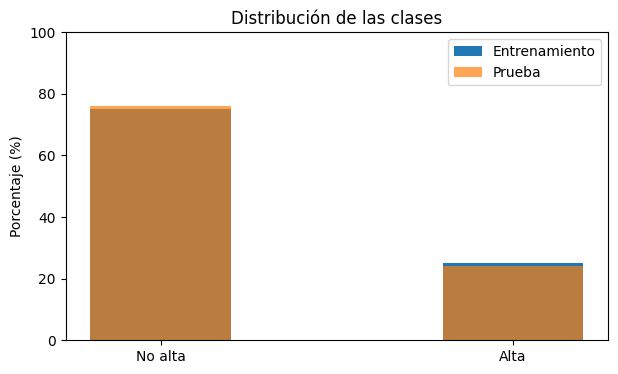

In [72]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7,4))

x = ["No alta", "Alta"]

ax.bar(
    x,
    distribucion_train["porcentaje"].to_list(),
    width=0.4,
    label="Entrenamiento"
)

ax.bar(
    x,
    distribucion_test["porcentaje"].to_list(),
    width=0.4,
    alpha=0.7,
    label="Prueba"
)

ax.set_ylabel("Porcentaje (%)")
ax.set_ylim(0, 100)
ax.set_title("Distribución de las clases")
ax.legend()

plt.show()

Se observa que la clase Alta demanda representa aproximadamente el 25 % de los registros de entrenamiento, mientras que la clase No alta demanda corresponde al 75 % restante. Esto indica un conjunto de datos moderadamente desbalanceado, situación frecuente en problemas reales de clasificación y que puede influir en la selección de métricas de evaluación y en el desempeño de los modelos.

In [73]:
# ============================================================
# 33. Árbol de decisión para clasificación
# ============================================================

from sklearn.tree import DecisionTreeClassifier

modelo_clf = DecisionTreeClassifier(
    criterion="gini",
    max_depth=8,
    min_samples_leaf=20,
    random_state=RANDOM_STATE
)

modelo_clf

DecisionTreeClassifier(max_depth=8, min_samples_leaf=20, random_state=42)

## Entrenamiento del clasificador


In [74]:
# ============================================================
# Entrenamiento del árbol de clasificación
# ============================================================

inicio_perf = perf_counter()
inicio_dt = datetime.now()

modelo_clf.fit(
    X_train,
    y_train_clf
)

tiempo_fit_clf = registrar_tiempo(
    "Entrenamiento Árbol de Clasificación",
    inicio_perf,
    inicio_dt
)

Entrenamiento Árbol de Clasificación: 11.34 segundos


## Predicción y evaluación del clasificador


In [75]:
# ============================================================
# Predicción
# ============================================================

inicio_perf = perf_counter()
inicio_dt = datetime.now()

pred_clf = modelo_clf.predict(X_test)

tiempo_pred_clf = registrar_tiempo(
    "Predicción Árbol de Clasificación",
    inicio_perf,
    inicio_dt
)


Predicción Árbol de Clasificación: 0.04 segundos


In [76]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy = accuracy_score(y_test_clf, pred_clf)
precision = precision_score(y_test_clf, pred_clf)
recall = recall_score(y_test_clf, pred_clf)
f1 = f1_score(y_test_clf, pred_clf)

print("=" * 60)
print("ÁRBOL DE DECISIÓN - CLASIFICACIÓN")
print("=" * 60)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")
print("=" * 60)

ÁRBOL DE DECISIÓN - CLASIFICACIÓN
Accuracy : 0.9344
Precision: 0.8686
Recall   : 0.8563
F1-score : 0.8625


## Matriz de confusión


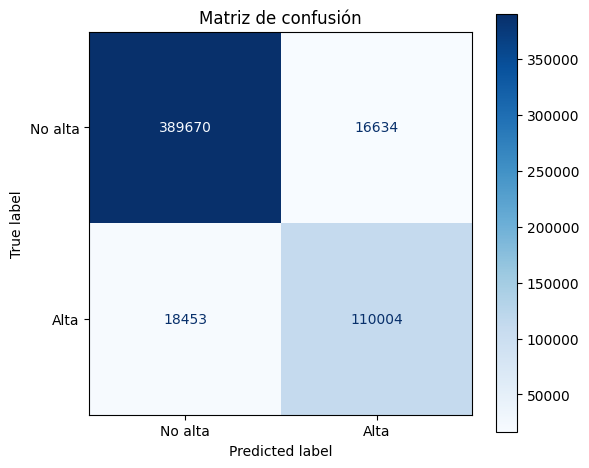

In [77]:
# ============================================================
# Matriz de confusión (gráfica)
# ============================================================

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test_clf,
    pred_clf
)

fig, ax = plt.subplots(figsize=(6,5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No alta", "Alta"]
)

disp.plot(
    cmap="Blues",          # Cambiar mapa de colores
    values_format="d",
    ax=ax,
    colorbar=True
)

ax.set_title("Matriz de confusión")

plt.tight_layout()
plt.show()

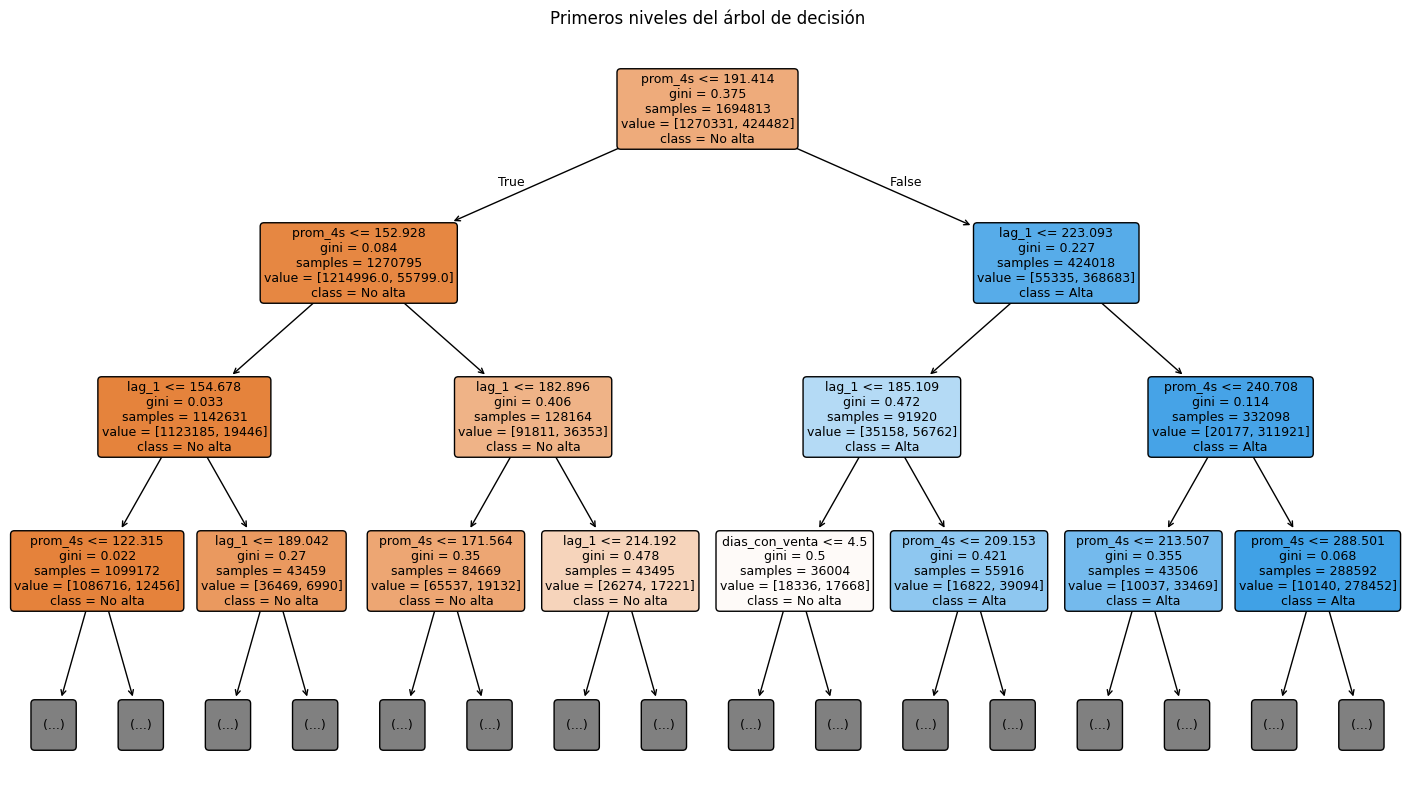

In [78]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(18,10))

plot_tree(
    modelo_clf,
    max_depth=3,
    feature_names=FEATURES,
    class_names=["No alta", "Alta"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Primeros niveles del árbol de decisión")
plt.show()

# 33. Resumen de tiempos


In [79]:
tiempo_total = perf_counter() - inicio_laboratorio_perf
resumen_tiempos = pd.DataFrame(registro_tiempos)
resumen_tiempos['Porcentaje del total (%)'] = (
    resumen_tiempos['Duración (s)'] / resumen_tiempos['Duración (s)'].sum() * 100
)
print(f'Tiempo total transcurrido: {tiempo_total:.2f} segundos')
resumen_tiempos[['Proceso','Duración (s)','Porcentaje del total (%)']]


Tiempo total transcurrido: 3682.66 segundos


,Proceso,Duración (s),Porcentaje del total (%)
0,Lectura del archivo Parquet,0.923251,0.325939
1,Feature Engineering temporal,1.199969,0.423629
2,Feature Engineering temporal,2.156154,0.761195
3,Eliminación de filas incompletas,0.068809,0.024292
4,Eliminación de filas incompletas,0.069953,0.024696
5,División temporal Train/Test,0.171529,0.060555
6,Preparación de matrices,0.318110,0.112304
7,Entrenamiento Regresión Lineal,4.004999,1.413899
8,Predicción Regresión Lineal,0.031909,0.011265
9,Entrenamiento Random Forest,143.954569,50.820800


# 34. Tiempo por proceso


In [80]:
resumen_ordenado = resumen_tiempos.sort_values('Duración (s)', ascending=True)
fig = px.bar(resumen_ordenado, x='Duración (s)', y='Proceso', orientation='h',
             text_auto='.2f', title='Tiempo de ejecución por proceso')
fig.show()


# 35. Línea de tiempo de ejecución

El gráfico tipo Gantt permite identificar el orden y duración de cada etapa.


In [81]:
fig = px.timeline(resumen_tiempos, x_start='Inicio', x_end='Fin', y='Proceso',
                  text='Duración (s)', title='Línea de tiempo de ejecución del laboratorio')
fig.update_yaxes(autorange='reversed')
fig.update_traces(texttemplate='%{text:.2f} s', textposition='inside')
fig.update_layout(xaxis_title='Tiempo', yaxis_title='Proceso')
fig.show()


# 36. Gráfico final: ventas reales y predicciones

Para cerrar el laboratorio agregaremos los resultados por semana y compararemos:

- ventas reales;
- baseline;
- Random Forest;
- XGBoost.


In [83]:
# ============================================================
# 36. Ventas reales y predicciones por semana
# ============================================================

import pandas as pd

resultados_test = test_modelo.select(
    [
        "fecha_semana",
        "target"
    ]
).to_pandas()

resultados_test["Baseline"] = pred_base
resultados_test["Random Forest"] = pred_rf
resultados_test["XGBoost"] = pred_xgb

# La fecha original corresponde a la semana de entrada.
# El target y las predicciones corresponden a la semana siguiente.
resultados_test["fecha_objetivo"] = (
    pd.to_datetime(resultados_test["fecha_semana"])
    + pd.Timedelta(weeks=1)
)

ventas_predichas_semana = (
    resultados_test
    .groupby(
        "fecha_objetivo",
        as_index=False
    )
    .agg({
        "target": "sum",
        "Baseline": "sum",
        "Random Forest": "sum",
        "XGBoost": "sum"
    })
    .rename(columns={
        "fecha_objetivo": "fecha_semana",
        "target": "Ventas reales"
    })
    .sort_values("fecha_semana")
)

ventas_predichas_semana.head()

,fecha_semana,Ventas reales,Baseline,Random Forest,XGBoost
0,2016-09-12,1.663262e+06,1.788633e+06,1.787667e+06,1806427.625
1,2016-09-19,1.635307e+06,1.662574e+06,1.735192e+06,1748842.750
2,2016-09-26,1.786081e+06,1.634273e+06,1.717835e+06,1726210.625
3,2016-10-03,1.829741e+06,1.787155e+06,1.749017e+06,1770685.375
4,2016-10-10,1.728745e+06,1.830665e+06,1.783455e+06,1800342.000


In [84]:
# ============================================================
# 36. Ventas reales y predicciones por semana
# ============================================================

import pandas as pd

resultados_test = test_modelo.select(
    [
        "fecha_semana",
        "target"
    ]
).to_pandas()

# Incorporación de las predicciones
resultados_test["Baseline"] = pred_base
resultados_test["Regresión Lineal"] = pred_lr
resultados_test["Random Forest"] = pred_rf
resultados_test["XGBoost"] = pred_xgb

# La fecha original corresponde a la semana de entrada.
# El target y las predicciones corresponden a la semana siguiente.
resultados_test["fecha_objetivo"] = (
    pd.to_datetime(resultados_test["fecha_semana"])
    + pd.Timedelta(weeks=1)
)

ventas_predichas_semana = (
    resultados_test
    .groupby(
        "fecha_objetivo",
        as_index=False
    )
    .agg({
        "target": "sum",
        "Baseline": "sum",
        "Regresión Lineal": "sum",
        "Random Forest": "sum",
        "XGBoost": "sum"
    })
    .rename(columns={
        "fecha_objetivo": "fecha_semana",
        "target": "Ventas reales"
    })
    .sort_values("fecha_semana")
)

ventas_predichas_semana.head()

,fecha_semana,Ventas reales,Baseline,Regresión Lineal,Random Forest,XGBoost
0,2016-09-12,1.663262e+06,1.788633e+06,1.760961e+06,1.787667e+06,1806427.625
1,2016-09-19,1.635307e+06,1.662574e+06,1.711403e+06,1.735192e+06,1748842.750
2,2016-09-26,1.786081e+06,1.634273e+06,1.716956e+06,1.717835e+06,1726210.625
3,2016-10-03,1.829741e+06,1.787155e+06,1.747012e+06,1.749017e+06,1770685.375
4,2016-10-10,1.728745e+06,1.830665e+06,1.763564e+06,1.783455e+06,1800342.000


In [85]:
# ============================================================
# 37. Comparación de ventas reales y predicciones
# ============================================================

import plotly.graph_objects as go

fig = go.Figure()

# Ventas reales
fig.add_trace(
    go.Scatter(
        x=ventas_predichas_semana["fecha_semana"],
        y=ventas_predichas_semana["Ventas reales"],
        mode="lines",
        name="Ventas reales",
        line=dict(
            color="black",
            width=4
        ),
        hovertemplate="%{y:,.0f}<extra></extra>"
    )
)

# Baseline
fig.add_trace(
    go.Scatter(
        x=ventas_predichas_semana["fecha_semana"],
        y=ventas_predichas_semana["Baseline"],
        mode="lines",
        name="Baseline",
        line=dict(
            color="darkorange",
            width=2,
            dash="dash"
        ),
        hovertemplate="%{y:,.0f}<extra></extra>"
    )
)

# Regresión Lineal
fig.add_trace(
    go.Scatter(
        x=ventas_predichas_semana["fecha_semana"],
        y=ventas_predichas_semana["Regresión Lineal"],
        mode="lines",
        name="Regresión Lineal",
        line=dict(
            color="green",
            width=3
        ),
        hovertemplate="%{y:,.0f}<extra></extra>"
    )
)

# Random Forest
fig.add_trace(
    go.Scatter(
        x=ventas_predichas_semana["fecha_semana"],
        y=ventas_predichas_semana["Random Forest"],
        mode="lines",
        name="Random Forest",
        line=dict(
            color="royalblue",
            width=3
        ),
        hovertemplate="%{y:,.0f}<extra></extra>"
    )
)

# XGBoost
fig.add_trace(
    go.Scatter(
        x=ventas_predichas_semana["fecha_semana"],
        y=ventas_predichas_semana["XGBoost"],
        mode="lines",
        name="XGBoost",
        line=dict(
            color="crimson",
            width=3
        ),
        hovertemplate="%{y:,.0f}<extra></extra>"
    )
)

fig.update_layout(
    title=dict(
        text="Comparación de ventas reales y predicciones",
        x=0.5,
        xanchor="center",
        font=dict(size=22)
    ),

    xaxis=dict(
        title="Semana",
        tickformat="%d-%b-%Y",
        tickangle=-45,
        showgrid=True,
        gridcolor="lightgray"
    ),

    yaxis=dict(
        title="Ventas totales",
        tickformat=",d",
        showgrid=True,
        gridcolor="lightgray"
    ),

    template="plotly_white",

    hovermode="x unified",

    legend=dict(
        title="Modelo",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    height=650,

    margin=dict(
        l=80,
        r=40,
        t=100,
        b=90
    )
)

fig.show()

# 34. Predicción de la próxima semana

Para proyectar la siguiente semana se utilizan las características disponibles en la última semana observada:

- ventas recientes;
- lags;
- promedio móvil;
- días en promoción;
- días con venta.

El modelo entrega una predicción para cada combinación tienda-producto. Luego se suman todas las predicciones para obtener la estimación global de la cadena.


In [86]:
# ============================================================
# Predicción de la próxima semana con Random Forest
# ============================================================

# Última fecha disponible en los datos supervisados
ultima_fecha = df_supervisado.select(
    pl.max("fecha_semana")
).item()

# Semana correlativa correspondiente a la última semana observada
ultima_semana_id = df_supervisado.select(
    pl.max("semana_id")
).item()

# Se utilizan las características de la última semana observada.
# El modelo generará la predicción de la semana siguiente.
datos_proxima_semana = (
    df_supervisado
    .filter(
        pl.col("fecha_semana") == ultima_fecha
    )
    .drop_nulls(FEATURES)
)

# Matriz de características
X_proxima_semana = (
    datos_proxima_semana
    .select(FEATURES)
    .to_numpy()
)

# No se utiliza StandardScaler porque Random Forest
# fue entrenado con las variables originales
prediccion_proxima_semana = (
    modelo_rf
    .predict(X_proxima_semana)
    .clip(min=0)
)

# Predicción total de ventas
prediccion_total_proxima_semana = (
    prediccion_proxima_semana.sum()
)

# Fecha correspondiente a la semana predicha
fecha_proxima_semana = (
    pd.Timestamp(ultima_fecha)
    + pd.Timedelta(weeks=1)
)

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  37 tasks      | elapsed:    0.0s
[Parallel(n_jobs=2)]: Done  50 out of  50 | elapsed:    0.1s finished


In [87]:
# ============================================================
# Ventas históricas semanales
# ============================================================

historico_semanal = (
    df
    .group_by("fecha_semana")
    .agg(
        pl.col("ventas")
        .sum()
        .alias("ventas_reales")
    )
    .sort("fecha_semana")
    .to_pandas()
)

historico_semanal["fecha_semana"] = pd.to_datetime(
    historico_semanal["fecha_semana"]
)

In [88]:
# ============================================================
# Ventas históricas y predicción de la próxima semana
# ============================================================

import pandas as pd
import plotly.graph_objects as go


# ------------------------------------------------------------
# 1. Asegurar que las fechas estén en formato datetime
# ------------------------------------------------------------

historico_semanal["fecha_semana"] = pd.to_datetime(
    historico_semanal["fecha_semana"]
)

fecha_proxima_semana = pd.Timestamp(
    fecha_proxima_semana
)


# ------------------------------------------------------------
# 2. Crear gráfico
# ------------------------------------------------------------

fig = go.Figure()


# Ventas históricas
fig.add_trace(
    go.Scatter(
        x=historico_semanal["fecha_semana"],
        y=historico_semanal["ventas_reales"],
        mode="lines+markers",
        name="Ventas reales",
        line=dict(
            color="black",
            width=3
        ),
        marker=dict(
            size=6
        ),
        hovertemplate=(
            "<b>Ventas reales</b><br>"
            "%{y:,.0f}"
            "<extra></extra>"
        )
    )
)


# Línea entre la última venta real y la predicción
fig.add_trace(
    go.Scatter(
        x=[
            historico_semanal["fecha_semana"].iloc[-1],
            fecha_proxima_semana
        ],
        y=[
            historico_semanal["ventas_reales"].iloc[-1],
            prediccion_total_proxima_semana
        ],
        mode="lines+markers",
        name="Predicción Random Forest",
        line=dict(
            color="royalblue",
            width=3,
            dash="dash"
        ),
        marker=dict(
            size=10
        ),
        hovertemplate=(
            "<b>Predicción Random Forest</b><br>"
            "%{y:,.0f}"
            "<extra></extra>"
        )
    )
)




fig.add_annotation(
    x=fecha_proxima_semana,
    y=prediccion_total_proxima_semana,
    text=(
        "Predicción<br>"
        f"<b>{prediccion_total_proxima_semana:,.0f}</b>"
    ),
    showarrow=True,
    arrowhead=2,
    arrowsize=1.2,
    arrowwidth=2,
    ax=40,
    ay=-60,
    bgcolor="white",
    bordercolor="royalblue",
    borderwidth=2
)
# ------------------------------------------------------------
# 3. Formato del gráfico
# ------------------------------------------------------------

fig.update_layout(
    title=dict(
        text="Ventas históricas y predicción de la próxima semana",
        x=0.5,
        xanchor="center",
        font=dict(
            size=22
        )
    ),

    xaxis=dict(
        title="Fecha de inicio de la semana",
        tickformat="%d-%b-%Y",
        tickangle=-45,
        showgrid=True,
        gridcolor="lightgray"
    ),

    yaxis=dict(
        title="Unidades vendidas",
        tickformat=",d",
        showgrid=True,
        gridcolor="lightgray"
    ),

    template="plotly_white",

    hovermode="x unified",

    legend=dict(
        title="Serie",
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    height=600,

    margin=dict(
        l=80,
        r=40,
        t=100,
        b=90
    )
)


# ------------------------------------------------------------
# 4. Mostrar gráfico
# ------------------------------------------------------------

fig.show()

In [89]:
# ============================================================
# Predicción detallada de la próxima semana
# ============================================================

predicciones_semana = (
    datos_proxima_semana
    .select(
        [
            "tienda",
            "producto"
        ]
    )
    .to_pandas()
)

predicciones_semana.insert(
    0,
    "fecha_semana",
    fecha_proxima_semana
)

predicciones_semana["ventas_estimadas"] = (
    prediccion_proxima_semana
    .round()
    .astype(int)
)

predicciones_semana.head(20)

,fecha_semana,tienda,producto,ventas_estimadas
0,2017-08-14,1,105575,80
1,2017-08-14,1,111223,47
2,2017-08-14,1,114790,21
3,2017-08-14,1,115611,52
4,2017-08-14,1,115850,19
5,2017-08-14,1,115892,22
6,2017-08-14,1,115893,36
7,2017-08-14,1,116017,22
8,2017-08-14,1,153267,35
9,2017-08-14,1,159156,92


In [90]:
# ============================================================
# Guardar predicciones en CSV
# ============================================================

nombre_archivo = "/content/prediccion_proxima_semana.csv"

predicciones_semana.to_csv(
    nombre_archivo,
    index=False,
    encoding="utf-8-sig"
)

print("=" * 60)
print("ARCHIVO GENERADO CORRECTAMENTE")
print("=" * 60)
print(f"Archivo : {nombre_archivo}")
print(f"Registros : {len(predicciones_semana):,}")
print(f"Tiendas : {predicciones_semana['tienda'].nunique()}")
print(f"Productos : {predicciones_semana['producto'].nunique()}")
print(
    f"Venta total estimada : "
    f"{predicciones_semana['ventas_estimadas'].sum():,.0f}"
)

ARCHIVO GENERADO CORRECTAMENTE
Archivo : /content/prediccion_proxima_semana.csv
Registros : 11,038
Tiendas : 54
Productos : 237
Venta total estimada : 1,706,916


# Conclusiones

Durante este laboratorio:

1. reutilizamos `Favorita_weekly.parquet`;
2. trabajamos con el esquema real generado en el módulo anterior;
3. utilizamos `fecha_semana` como llave temporal única;
4. creamos `semana_id` para representar el orden cronológico sin reiniciarlo cada año;
5. eliminamos la última semana incompleta;
6. verificamos duplicados con la llave correcta: fecha, tienda y producto;
7. analizamos las ventas agregadas de toda la cadena;
8. incorporamos `dias_promocion` y `dias_con_venta`;
9. construimos lags, promedio móvil y target;
10. realizamos una división temporal de entrenamiento y prueba;
11. comparamos un modelo base, Random Forest y XGBoost;
12. proyectamos las ventas de la siguiente semana.

> La corrección metodológica principal consiste en no utilizar únicamente el número de semana, porque se repite cada año. La fecha semanal y el correlativo temporal permiten conservar la secuencia cronológica completa.
